# Exploração dos Dados

In [ ]:
# importando de bibliotecas     
from pathlib import Path
import pandas as pd
import numpy as np

In [ ]:
# salvando leitura do arquivo em variável
df = pd.read_parquet(
    "../data/interim/inpe/focos/focos_br_todos-sats_2025.parquet"
)
df_original = df.copy()      # backup explícito

In [ ]:
# verificando quantidade de linhas e colunas
df.shape

(3466399, 13)

In [ ]:
# verificando tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3466399 entries, 0 to 3466398
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   latitude               float64
 1   longitude              float64
 2   data_pas               str    
 3   satelite               str    
 4   pais                   str    
 5   estado                 str    
 6   municipio              str    
 7   bioma                  str    
 8   numero_dias_sem_chuva  float64
 9   precipitacao           float64
 10  risco_fogo             float64
 11  id_area_industrial     int64  
 12  frp                    float64
dtypes: float64(6), int64(1), str(6)
memory usage: 544.7 MB


In [ ]:
# verificando quantidade e percentual de valores nulos por coluna
qtd_nulos = df.isnull().sum()
pct_nulos = (qtd_nulos / len(df)) * 100
nulos_df = pd.DataFrame(
    {"qtd_nulos": qtd_nulos, 
     "pct_nulos": pct_nulos}
     ).sort_values(by="qtd_nulos", ascending=False)

nulos_df

,qtd_nulos,pct_nulos
numero_dias_sem_chuva,58485,1.687198
precipitacao,58485,1.687198
risco_fogo,58485,1.687198
frp,45481,1.312053
bioma,3,0.000087
pais,0,0.000000
satelite,0,0.000000
data_pas,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [ ]:
# visualizando as primeiras linhas do dataframe
df.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
0,-19.7334,-55.399899,2025-01-01 00:35:00,METOP-B,Brasil,MATO GROSSO DO SUL,AQUIDAUANA,Pantanal,7.0,0.00,0.74,0,NaN
1,-15.2145,-60.173901,2025-01-01 00:38:00,METOP-B,Brasil,MATO GROSSO,VILA BELA DA SANTÍSSIMA TRINDADE,Amazônia,4.0,0.72,0.65,0,NaN
2,-15.2090,-60.198799,2025-01-01 00:38:00,METOP-B,Brasil,MATO GROSSO,VILA BELA DA SANTÍSSIMA TRINDADE,Amazônia,3.0,1.32,0.58,0,NaN
3,-12.2099,-49.326199,2025-01-01 00:38:00,METOP-B,Brasil,TOCANTINS,FIGUEIRÓPOLIS,Cerrado,1.0,0.00,0.10,0,NaN
4,-12.2082,-49.318901,2025-01-01 00:38:00,METOP-B,Brasil,TOCANTINS,FIGUEIRÓPOLIS,Cerrado,1.0,0.00,0.14,0,NaN


In [ ]:
# Salvando coluna de data convertida (de string para datetime, sem alterar o df) em uma variável
datas = pd.to_datetime( df["data_pas"])

# salvando uma cópia do dataframe filtrado (país = Brasil)
brasil = df[df["pais"] == "Brasil"].copy()

# aplicando a conversão de string para datetime na coluna "data_pas" do dataframe "brasil"
brasil["data_pas"] = pd.to_datetime(brasil["data_pas"])

#Data convertida de string para datetime64 com sucesso

In [ ]:
# Confere os valores únicos de id_area_industrial
print(brasil["id_area_industrial"].value_counts())

id_area_industrial
0    3466399
Name: count, dtype: int64


- Nenhum foco no dataset é de área industrial
- Todos os tipos estão corretos
- id_area_industrial é uma coluna sem informação útil nesse recorte de dados
- Está pronto para partir para o agrupamento e análise de incidências

In [35]:
brasil.isnull().sum()

latitude                     0
longitude                    0
data_pas                     0
satelite                     0
pais                         0
estado                       0
municipio                    0
bioma                        3
numero_dias_sem_chuva    58485
precipitacao             58485
risco_fogo               58485
id_area_industrial           0
frp                      45481
dtype: int64

Os 58.485 nulos em numero_dias_sem_chuva, precipitacao e risco_fogo sendo exatamente iguais não é coincidência — provavelmente são as mesmas linhas sem dados meteorológicos.

In [19]:
# Verifica se são as mesmas linhas
brasil[brasil["numero_dias_sem_chuva"].isnull()].isna().sum()

latitude                     0
longitude                    0
data_pas                     0
satelite                     0
pais                         0
estado                       0
municipio                    0
bioma                        0
numero_dias_sem_chuva    58485
precipitacao             58485
risco_fogo               58485
id_area_industrial           0
frp                        507
dtype: int64

In [20]:
# Verifica como os nulos estão distribuídos entre as colunas "satelite", "bioma" e "estado"
mask = brasil["numero_dias_sem_chuva"].isnull()

brasil[mask][["satelite", "bioma", "estado"]].value_counts().head(10)

satelite  bioma     estado  
NOAA-21   Amazônia  PARÁ        3576
NOAA-20   Amazônia  PARÁ        3284
GOES-19   Cerrado   MARANHÃO    2828
NPP-375   Amazônia  PARÁ        2449
GOES-19   Amazônia  PARÁ        2264
                    MARANHÃO    2021
NOAA-20   Cerrado   MARANHÃO    1936
NOAA-21   Cerrado   MARANHÃO    1819
NOAA-20   Caatinga  CEARÁ       1553
NPP-375   Caatinga  CEARÁ       1486
Name: count, dtype: int64

Os nulos estão espalhados por vários satélites e regiões diferentes — não é um problema pontual, é uma característica do dado mesmo. Satélites como NOAA-21, NOAA-20, GOES-19 e NPP-375 simplesmente não fornecem dados meteorológicos, só a localização do foco.

**Conclusão prática:**
Para análise de incidências por região → ignore os nulos, não afetam nada.
Para análises de seca/risco/intensidade → filtre só quando for usar essas colunas

# Respondendo as Perguntas de Negócio

### 1. Quais regiões do Brasil (regiões, estados e municípios) apresentam maior incidências de queimadas?
Objetivo: Identificar áreas  prioritárias para monitoramento e prevenção.

In [ ]:
# Contagem de focos por estado
queimadas_por_estado = (
    brasil.groupby('estado')
    .size()
    .reset_index(name='total_focos')
    .sort_values('total_focos', ascending=False)
)

queimadas_por_estado['pct_focos'] = round((queimadas_por_estado['total_focos'] / queimadas_por_estado['total_focos'].sum()) * 100, 2)
queimadas_por_estado['acc_focos'] = queimadas_por_estado['pct_focos'].cumsum()

print(f'Número de estados com focos de queimada: {len(queimadas_por_estado)}')

queimadas_por_estado

Número de estados com focos de queimada: 27


,estado,total_focos,pct_focos,acc_focos
9,MARANHÃO,588744,16.98,16.98
26,TOCANTINS,407909,11.77,28.75
10,MATO GROSSO,384854,11.10,39.85
17,PIAUÍ,366446,10.57,50.42
15,PARÁ,332780,9.60,60.02
4,BAHIA,307664,8.88,68.90
12,MINAS GERAIS,194643,5.62,74.52
8,GOIÁS,182889,5.28,79.80
3,AMAZONAS,142928,4.12,83.92
5,CEARÁ,94142,2.72,86.64


In [ ]:
# Por município (top 20)
queimadas_por_municipio = (
    brasil.groupby(["estado", "municipio"])
    .size()
    .reset_index(name="total_focos")
    .sort_values("total_focos", ascending=False)
)

queimadas_por_municipio['pct_focos'] = round((queimadas_por_municipio['total_focos'] / queimadas_por_municipio['total_focos'].sum()) * 100, 2)
queimadas_por_municipio['acc_focos'] = queimadas_por_municipio['pct_focos'].cumsum()

print(f'Número de estados com focos de queimada: {len(queimadas_por_municipio)}')

queimadas_por_municipio.head(20)

Número de estados com focos de queimada: 5512


,estado,municipio,total_focos,pct_focos,acc_focos
1371,MATO GROSSO,COLNIZA,42141,1.22,1.22
1241,MARANHÃO,MIRADOR,38521,1.11,2.33
5465,TOCANTINS,PARANÃ,33659,0.97,3.30
1147,MARANHÃO,BALSAS,30721,0.89,4.19
144,AMAZONAS,APUÍ,27220,0.79,4.98
1131,MARANHÃO,ALTO PARNAÍBA,26362,0.76,5.74
5439,TOCANTINS,LAGOA DA CONFUSÃO,24354,0.70,6.44
3569,PIAUÍ,URUÇUÍ,24025,0.69,7.13
333,BAHIA,FORMOSA DO RIO PRETO,23656,0.68,7.81
565,BAHIA,SÃO DESIDÉRIO,23548,0.68,8.49


### 2. Quais biomas concentram o maior número de foco de queimadas?

Objetivo: Entender quais ecossistemas são mais vulneráveis aos incêndios.

In [38]:
# Por bioma
queimadas_por_bioma = (
    brasil.groupby("bioma")
    .size()
    .reset_index(name="total_focos")
    .sort_values("total_focos", ascending=False)
)

queimadas_por_bioma['pct_focos'] = round((queimadas_por_bioma['total_focos'] / queimadas_por_bioma['total_focos'].sum()) * 100, 2)
queimadas_por_bioma['acc_focos'] = queimadas_por_bioma['pct_focos'].cumsum()

print(f'Número de estados com focos de queimada: {len(queimadas_por_bioma)}')

queimadas_por_bioma

Número de estados com focos de queimada: 6


,bioma,total_focos,pct_focos,acc_focos
2,Cerrado,1784865,51.49,51.49
0,Amazônia,975655,28.15,79.64
1,Caatinga,445091,12.84,92.48
3,Mata Atlântica,219855,6.34,98.82
5,Pantanal,28936,0.83,99.65
4,Pampa,11994,0.35,100.00


### 3. Existe sazonalidade na ocorrência das queimadas?
Objetivo: Identificar se há meses com concentração maior de focos, indicando padrão sazonal ligado à estação seca.

#### Sazonalidade por bioma

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ordem_meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez',
}

# Focos totais por mês
brasil['mes'] = brasil['data_pas'].dt.month

focos_por_mes = (
    brasil.groupby('mes')
    .size()
    .reset_index(name='total_focos')
)

focos_por_mes['mes_nome'] = focos_por_mes['mes'].map(ordem_meses)
focos_por_mes['pct_mes'] = (focos_por_mes['total_focos'] / focos_por_mes['total_focos'].sum() * 100).round(1)

focos_por_mes = focos_por_mes[['mes', 'mes_nome', 'total_focos', 'pct_mes']]
focos_por_mes

,mes,mes_nome,total_focos,pct_mes
0,1,Jan,63439,1.8
1,2,Fev,41395,1.2
2,3,Mar,49888,1.4
3,4,Abr,29801,0.9
4,5,Mai,107679,3.1
5,6,Jun,168163,4.9
6,7,Jul,243608,7.0
7,8,Ago,594309,17.1
8,9,Set,833039,24.0
9,10,Out,823767,23.8


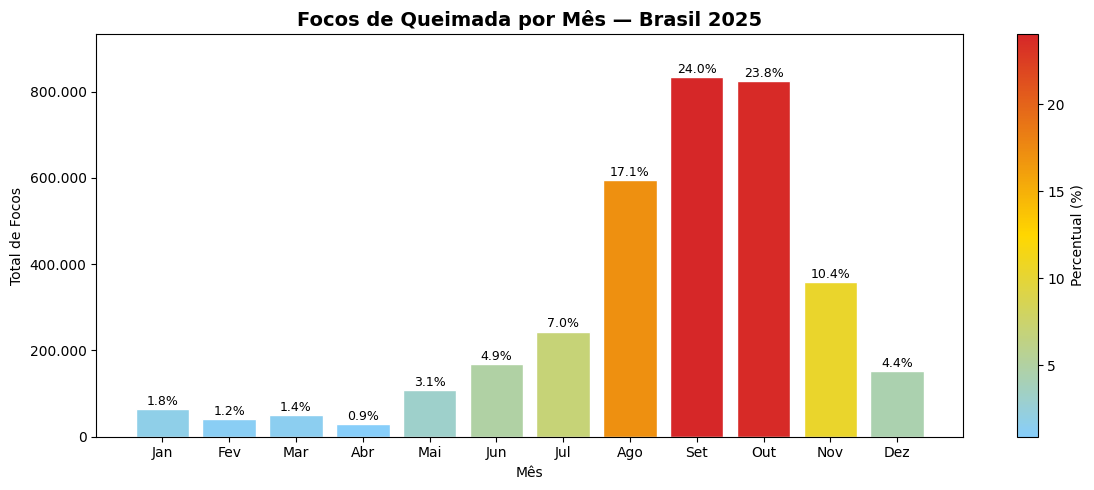

In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 5))

# Normaliza os percentuais entre 0 e 1
norm = mcolors.Normalize(
    vmin=focos_por_mes['pct'].min(),
    vmax=focos_por_mes['pct'].max()
)

# Gradiente azul claro -> vermelho
cmap = mcolors.LinearSegmentedColormap.from_list(
    'azul_amarelo_vermelho',
    ['#87CEFA', '#FFD700', '#d62728']
)

cores = cmap(norm(focos_por_mes['pct']))

barras = ax.bar(
    focos_por_mes['mes_nome'],
    focos_por_mes['total_focos'],
    color=cores,
    edgecolor='white'
)

for bar, pct in zip(barras, focos_por_mes['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f'{pct}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)

ax.set_title('Focos de Queimada por Mês — Brasil 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Total de Focos')
ax.set_ylim(0, focos_por_mes['total_focos'].max() * 1.12)

# Barra de cores opcional
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percentual (%)')

plt.tight_layout()
plt.show()

#### Sazonalidade por bioma
Cada bioma tem seu próprio regime hídrico. O heatmap abaixo permite comparar o pico sazonal de cada um.

In [63]:
# Focos por mês e bioma
focos_mes_bioma = (
    brasil.dropna(subset=['bioma'])
    .groupby(['bioma', 'mes'])
    .size()
    .reset_index(name='total_focos')
)

# Normaliza dentro de cada bioma (% do total anual do bioma) para comparação justa
focos_mes_bioma['pct_bioma'] = (
    focos_mes_bioma.groupby('bioma')['total_focos']
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

focos_mes_bioma['mes_nome'] = focos_mes_bioma['mes'].map(ordem_meses)
focos_mes_bioma['pct_mes'] = (focos_mes_bioma['total_focos'] / focos_mes_bioma['total_focos'].sum() * 100).round(1)

focos_mes_bioma = focos_mes_bioma[['mes', 'mes_nome', 'bioma', 'total_focos', 'pct_mes']]
focos_mes_bioma

,mes,mes_nome,bioma,total_focos,pct_mes
0,1,Jan,Amazônia,24237,0.7
1,2,Fev,Amazônia,5417,0.2
2,3,Mar,Amazônia,12805,0.4
3,4,Abr,Amazônia,3900,0.1
4,5,Mai,Amazônia,20988,0.6
...,...,...,...,...,...
67,8,Ago,Pantanal,1166,0.0
68,9,Set,Pantanal,7891,0.2
69,10,Out,Pantanal,10515,0.3
70,11,Nov,Pantanal,3092,0.1


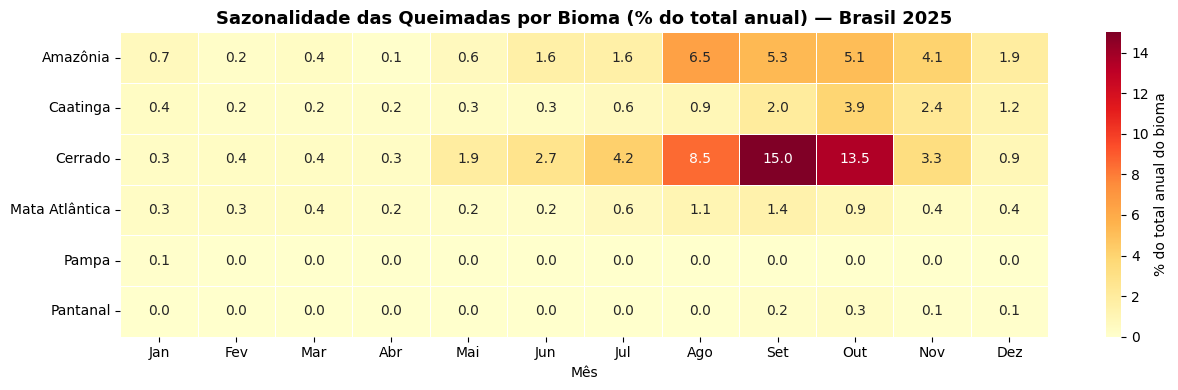

In [65]:
import seaborn as sns

# Pivot: linhas = bioma, colunas = mês (em ordem)
pivot = focos_mes_bioma.pivot(index='bioma', columns='mes', values='pct_mes')
pivot.columns = [ordem_meses[m] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': '% do total anual do bioma'},
    ax=ax,
)
ax.set_title('Sazonalidade das Queimadas por Bioma (% do total anual) — Brasil 2025',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

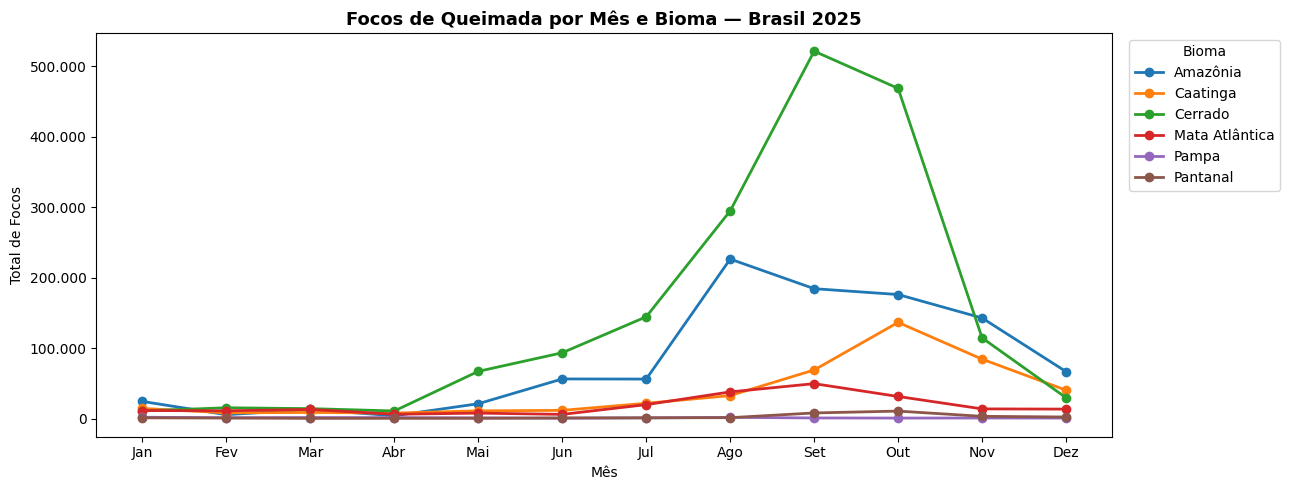

In [66]:
# Linha do tempo comparativa: focos absolutos por mês, separado por bioma
fig, ax = plt.subplots(figsize=(13, 5))

for bioma, grupo in focos_mes_bioma.groupby("bioma"):
    ax.plot(grupo["mes"], grupo["total_focos"], marker="o", label=bioma, linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([ordem_meses[m] for m in range(1, 13)])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
ax.set_title("Focos de Queimada por Mês e Bioma — Brasil 2025", fontsize=13, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Total de Focos")
ax.legend(title="Bioma", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Conclusão esperada:**
- O Brasil apresenta sazonalidade clara, com pico entre **agosto e outubro** (estação seca).
- O **Cerrado** domina em volume absoluto e concentra seu pico nesse período.
- A **Amazônia** tem pico similar, mas antecipado (Jul–Set).
- O **Pantanal** pode ter pico diferente dependendo das cheias do ciclo hidrológico local.
- A **Caatinga** tende a concentrar focos entre **setembro e novembro**, quando a seca do semiárido é mais intensa.

### 4. Qual a relação entre períodos de seca e o aumento dos focos de queimadas?
Objetivo: Avaliar a influência das condições climáticas na ocorrência dos incêndios.

In [72]:
# Filtra linhas com dados meteorológicos
df_met = brasil.dropna(subset=['numero_dias_sem_chuva', 'precipitacao', 'risco_fogo'])

# Agrupa por mês: calcula média de dias sem chuva e total de focos
seca_mes = (
  df_met.groupby('mes')
  .agg(
    total_focos=('mes', 'count'),
    media_dias_sem_chuva=('numero_dias_sem_chuva', 'mean'),
    media_precipitacao=('precipitacao', 'mean'),
    media_risco_fogo=('risco_fogo', 'mean'),
    ).reset_index()
  )

seca_mes['mes_nome'] = seca_mes['mes'].map(ordem_meses)

seca_mes

,mes,total_focos,media_dias_sem_chuva,media_precipitacao,media_risco_fogo,mes_nome
0,1,63439,-40.133530,2.024732,-21.057039,Jan
1,2,41395,-37.349173,1.521976,-31.467483,Fev
2,3,49888,-24.163386,1.115524,-29.135654,Mar
3,4,29801,-21.835308,1.409574,-23.846610,Abr
4,5,107679,6.664754,0.222043,-11.833245,Mai
5,6,168163,16.350678,0.132255,-10.053581,Jun
6,7,243608,24.394400,0.246205,-9.842618,Jul
7,8,594309,20.147235,0.214396,-6.486601,Ago
8,9,833039,26.766480,0.375718,-5.418853,Set
9,10,823480,8.543772,0.532152,-3.853124,Out


Correlação de Pearson (dias sem chuva × focos): r = 0.630  |  p-value = 0.0282


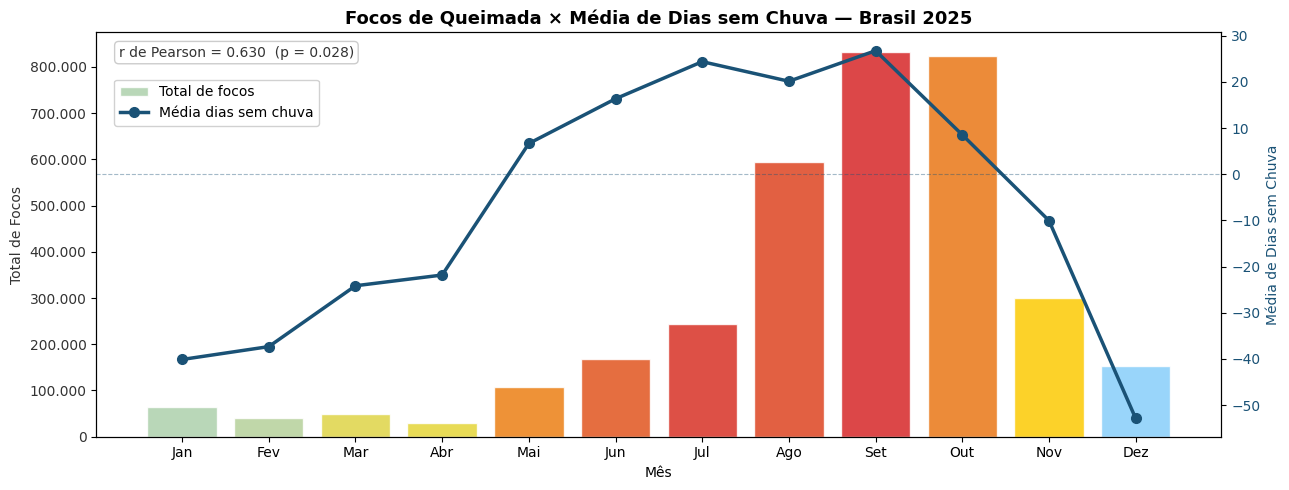

In [85]:
from scipy import stats

# Correlação de Pearson: dias sem chuva × total de focos
r, p = stats.pearsonr(seca_mes['media_dias_sem_chuva'], seca_mes['total_focos'])
print(f"Correlação de Pearson (dias sem chuva × focos): r = {r:.3f}  |  p-value = {p:.4f}")

fig, ax1 = plt.subplots(figsize=(13, 5))

# Eixo esquerdo: focos (barras)
cmap = mcolors.LinearSegmentedColormap.from_list('seca', ['#87CEFA', '#FFD700', '#d62728'])
norm = mcolors.Normalize(
    vmin=seca_mes['media_dias_sem_chuva'].min(),
    vmax=seca_mes['media_dias_sem_chuva'].max()
)
cores = cmap(norm(seca_mes['media_dias_sem_chuva']))

barras = ax1.bar(
    seca_mes['mes_nome'],
    seca_mes['total_focos'],
    color=cores,
    alpha=0.85,
    edgecolor='white',
    label='Total de focos'
)
ax1.set_ylabel('Total de Focos', color='#333333')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
ax1.tick_params(axis='y', labelcolor='#333333')

# Eixo direito: média de dias sem chuva (linha)
ax2 = ax1.twinx()
ax2.plot(
    seca_mes['mes_nome'],
    seca_mes['media_dias_sem_chuva'],
    color='#1a5276',
    linewidth=2.5,
    marker='o',
    markersize=7,
    label='Média dias sem chuva'
)
ax2.set_ylabel('Média de Dias sem Chuva', color='#1a5276')
ax2.tick_params(axis='y', labelcolor='#1a5276')
ax2.axhline(0, color='#1a5276', linewidth=0.8, linestyle='--', alpha=0.4)

# Estatísticas (canto superior esquerdo)
ax1.annotate(
    f'r de Pearson = {r:.3f}  (p = {p:.3f})',
    xy=(0.02, 0.94), xycoords='axes fraction',
    fontsize=10, color='#333333',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc')
)

# Legenda unificada — posicionada abaixo da anotação
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    linhas1 + linhas2, labels1 + labels2,
    bbox_to_anchor=(0.01, 0.90), loc='upper left',
    framealpha=0.9, edgecolor='#cccccc'
)

ax1.set_title(
    'Focos de Queimada × Média de Dias sem Chuva — Brasil 2025',
    fontsize=13, fontweight='bold'
)
ax1.set_xlabel('Mês')
plt.tight_layout()
plt.show()

**Conclusão:**
- A correlação de Pearson entre a média de dias sem chuva e o total de focos confirma a relação direta: quanto mais tempo sem precipitação, maior o número de incêndios.
- O gradiente de cores das barras reforça visualmente essa lógica: barras vermelhas (meses mais secos) concentram os maiores volumes de focos.
- A linha de zero no eixo direito separa os meses com saldo negativo (precipitação recente, poucos focos) dos meses com saldo positivo (seca acumulada, muitos focos).
- **Set e Out** lideram tanto em dias sem chuva quanto em focos — exatamente o pico da estação seca no Cerrado e na Amazônia.

### 5. Qual a relação entre os biomas e o aumento dos focos de queimadas?

Objetivo: Avaliar a influência das características do próprio bioma na ocorrência dos incêndios. 